# DB MoveOptimizer - Tool Use Foundation

Notebook 03 introduces **tool calling** — the core mechanism that turns a plain LLM call into an agent.

We add a single tool: `lookup_subscriptions`, which reads `data/subscriptions.csv` and returns the DB product catalog. The agent decides autonomously when to call it.

New LangGraph concepts introduced here:
- `@tool` decorator to define a callable tool
- `ToolNode` to execute tool calls returned by the model
- **Conditional edges**: route to `tool_node` if the model called a tool, else go to END
- The **ReAct loop**: agent → tool → agent → END

## Notebook Outline
1. Environment Setup
2. Initialize API Client
3. Load Subscription Catalog
4. Define the `lookup_subscriptions` Tool
5. Set Up State and Agent Node
6. Build the Tool-Use Workflow
7. Visualise the Graph
8. Test: Agent Queries the Catalog

## 1. Environment Setup

In [10]:
import subprocess, sys

def install_packages(packages):
    for pkg in packages:
        try:
            __import__(pkg.split('==')[0].replace('-', '_'))
            print(f'✓ {pkg} already installed')
        except ImportError:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
            print(f'✓ {pkg} installed')

install_packages(['openai', 'langgraph', 'langchain', 'langchain-core', 'langchain-openai', 'pandas'])


✓ openai already installed
✓ langgraph already installed
✓ langchain already installed
✓ langchain-core already installed
✓ langchain-openai already installed
✓ pandas already installed


In [11]:
import os
from openai import OpenAI

UNI_GPT_BASE_URL = 'https://chat.kiconnect.nrw/api/v1'
UNI_GPT_MODEL    = 'Openai GPT OSS 120B'
UNI_GPT_API_KEY  = os.getenv('UNI_GPT_API_KEY', '')

if not UNI_GPT_API_KEY:
    from getpass import getpass
    UNI_GPT_API_KEY = getpass('Enter your University GPT API Key: ')

client = OpenAI(base_url=UNI_GPT_BASE_URL, api_key=UNI_GPT_API_KEY)
print('✓ API client ready')


✓ API client ready


## 3. Load Subscription Catalog

Read `data/subscriptions.csv` once at startup and keep it in memory.
The tool filters and returns rows on demand.

In [12]:
import pandas as pd
from pathlib import Path

CATALOG_PATH = Path('../data/subscriptions.csv')
catalog_df   = pd.read_csv(CATALOG_PATH)

print(f'✓ Subscription catalog loaded: {len(catalog_df)} products')
catalog_df


✓ Subscription catalog loaded: 7 products


,product_id,product_name,type,monthly_cost_eur,annual_cost_eur,discount_pct,travel_class,coverage_scope,min_commitment_months,notes
0,DT-49,Deutschlandticket,subscription,49.00,588.0,0,2,regional_only,1,Unlimited regional/local transport nationwide;...
1,BC25-2,BahnCard 25 (2nd class),card,4.83,57.9,25,2,IC_ICE_RE_national,12,25% discount on all DB long-distance and regio...
2,BC25-1,BahnCard 25 (1st class),card,9.66,115.9,25,1,IC_ICE_RE_national,12,25% discount on all DB long-distance and regio...
3,BC50-2,BahnCard 50 (2nd class),card,19.50,234.0,50,2,IC_ICE_RE_national,12,50% discount on all DB long-distance and regio...
4,BC50-1,BahnCard 50 (1st class),card,39.08,469.0,50,1,IC_ICE_RE_national,12,50% discount on all DB long-distance and regio...
5,BC100-2,BahnCard 100 (2nd class),card,366.25,4395.0,100,2,IC_ICE_RE_SBahn_national,12,Unlimited travel on entire DB network; 2nd class
6,BC100-1,BahnCard 100 (1st class),card,618.83,7426.0,100,1,IC_ICE_RE_SBahn_national,12,Unlimited travel on entire DB network; 1st class


## 4. Define the `lookup_subscriptions` Tool

The `@tool` decorator from LangChain turns a plain Python function into something
the model can call by name. The docstring becomes the tool description the model reads
when deciding whether to invoke it — so it matters.

In [13]:
from langchain_core.tools import tool


@tool
def lookup_subscriptions(filter_type: str = 'all') -> str:
    """Look up Deutsche Bahn subscription products from the catalog.

    Args:
        filter_type: Filter by product type.
                     Use 'card' for BahnCards, 'subscription' for flat-rate passes,
                     or 'all' for the full catalog.

    Returns:
        A formatted table of matching DB subscription products with prices and conditions.
    """
    df = catalog_df.copy()
    if filter_type != 'all':
        df = df[df['type'] == filter_type]
    if df.empty:
        return f"No products found for filter_type='{filter_type}'."
    return df.to_string(index=False)


tools = [lookup_subscriptions]

# Sanity check
print('Tool test (filter_type="card"):')
print(lookup_subscriptions.invoke({'filter_type': 'card'}))


Tool test (filter_type="card"):
product_id             product_name type  monthly_cost_eur  annual_cost_eur  discount_pct  travel_class           coverage_scope  min_commitment_months                                                                notes
    BC25-2  BahnCard 25 (2nd class) card              4.83             57.9            25             2       IC_ICE_RE_national                     12 25% discount on all DB long-distance and regional tickets; 2nd class
    BC25-1  BahnCard 25 (1st class) card              9.66            115.9            25             1       IC_ICE_RE_national                     12 25% discount on all DB long-distance and regional tickets; 1st class
    BC50-2  BahnCard 50 (2nd class) card             19.50            234.0            50             2       IC_ICE_RE_national                     12 50% discount on all DB long-distance and regional tickets; 2nd class
    BC50-1  BahnCard 50 (1st class) card             39.08            469.0         

## 5. Set Up State and Agent Node

We use `MessagesState` — LangGraph's built-in state that carries a list of messages
with an `add_messages` reducer. This is required for tool calling because the model returns
an `AIMessage` containing `tool_calls`, and `ToolNode` appends `ToolMessage` results.

The agent node binds tools to the model so the API knows what functions are available.

In [14]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition


OPTIMIZER_SYSTEM_PROMPT = (
    'You are a Deutsche Bahn mobility optimizer. '
    'When asked about subscriptions or cost optimisation, use the lookup_subscriptions tool '
    'to retrieve the current product catalog before answering. '
    'Be concise and factual. Always cite product names and prices from the catalog.'
)

# Wrap the university endpoint in a LangChain-compatible chat model
llm = ChatOpenAI(
    model=UNI_GPT_MODEL,
    openai_api_key=UNI_GPT_API_KEY,
    openai_api_base=UNI_GPT_BASE_URL,
    temperature=0.0,
)

# Bind tools so the model knows they exist
llm_with_tools = llm.bind_tools(tools)


def agent_node(state: MessagesState) -> MessagesState:
    """Call the LLM with tools bound. Returns the new AI message."""
    messages = [SystemMessage(content=OPTIMIZER_SYSTEM_PROMPT)] + state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}


print('✓ LLM with tools bound')
print('✓ agent_node defined')


✓ LLM with tools bound
✓ agent_node defined


## 6. Build the Tool-Use Workflow

The graph now has a **loop**: after the agent runs, we check whether it called a tool.
- If **yes** → `tool_node` executes the call and routes back to `agent` (model sees the result)
- If **no** → END

This is the standard **ReAct** pattern in LangGraph.

In [15]:
tool_node = ToolNode(tools)

workflow = StateGraph(MessagesState)
workflow.add_node('agent', agent_node)
workflow.add_node('tools', tool_node)  # must be named 'tools' — that's what tools_condition routes to

workflow.add_edge(START, 'agent')

# tools_condition routes to 'tools' when tool_calls are present, else END
workflow.add_conditional_edges('agent', tools_condition)

# After the tool runs, always return to agent so it can read the result
workflow.add_edge('tools', 'agent')

graph = workflow.compile()

print('✓ Tool-use graph compiled')
print('''
Workflow:
  START
    ↓
  agent ── calls tool? ── YES ──→ tools
    ↑                               │
    └───────────────────────────────┘
    │
   NO
    ↓
  END
''')

✓ Tool-use graph compiled

Workflow:
  START
    ↓
  agent ── calls tool? ── YES ──→ tools
    ↑                               │
    └───────────────────────────────┘
    │
   NO
    ↓
  END



## 7. Visualise the Graph


┌─────────────┐
│    START    │
└──────┬──────┘
       │
       ▼
┌──────────────────┐
│     agent        │◄──────────────┐
│  (LLM + tools)   │               │
└────────┬─────────┘           tool result
         │                         │
  tool call?              ┌─────────────┐
    YES  │                │    tools    │
         └───────────────►│ (executes)  │
    NO   │                └─────────────┘
         ▼
       ┌─────┐
       │ END │
       └─────┘



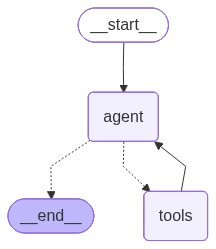

In [16]:
print('''
┌─────────────┐
│    START    │
└──────┬──────┘
       │
       ▼
┌──────────────────┐
│     agent        │◄──────────────┐
│  (LLM + tools)   │               │
└────────┬─────────┘           tool result
         │                         │
  tool call?              ┌─────────────┐
    YES  │                │    tools    │
         └───────────────►│ (executes)  │
    NO   │                └─────────────┘
         ▼
       ┌─────┐
       │ END │
       └─────┘
''')

from IPython.display import display, Image

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

## 8. Test: Agent Queries the Catalog

We ask a question that requires the agent to call `lookup_subscriptions` to answer correctly.
Watch the message trace below to see the ReAct loop in action.

In [17]:
from langchain_core.messages import HumanMessage

query = (
    'I travel Köln–Frankfurt 3 times a month by IC train (2nd class). '
    'A Flexpreis ticket costs around €89 each way. '
    'I currently have no subscription. '
    'What DB subscription product would save me the most money?'
)

print('User query:')
print(query)
print('\n' + '=' * 60)

result = graph.invoke({'messages': [HumanMessage(content=query)]})

print('\n' + '=' * 60)
print('AGENT RESPONSE')
print('=' * 60)
print(result['messages'][-1].content)
print('=' * 60)
print(f"\nTotal messages in state: {len(result['messages'])}")
print('Message types:', [type(m).__name__ for m in result['messages']])


User query:
I travel Köln–Frankfurt 3 times a month by IC train (2nd class). A Flexpreis ticket costs around €89 each way. I currently have no subscription. What DB subscription product would save me the most money?


AGENT RESPONSE
**Best DB subscription for your travel pattern (Köln ↔ Frankfurt, 3 round‑trips / month, 2nd class, Flexpreis ≈ €89 each way):**

| Product | Monthly fee | Discount on long‑distance tickets | Net monthly cost with your 6 tickets* |
|---------|-------------|-----------------------------------|----------------------------------------|
| **BahnCard 50 (2nd class)** | **€19.50** | **50 %** off each ticket | **≈ €286.5** |
| BahnCard 25 (2nd class) | €4.83 | 25 % off | €405.3 |
| BahnCard 100 (2nd class) | €366.25 | Unlimited (no per‑ticket price) | €366.25 |
| (1st‑class cards are more expensive and not relevant for 2nd‑class travel) |

\*Without a card you would pay 6 × €89 = **€534** per month.

### Why BahnCard 50 (2nd class) is optimal
- **Discount:** 50 % 

### Inspect the Full Message Trace

Print every message to see exactly what happened: the tool call request from the model,
the raw tool result, and the final answer.

In [18]:
for i, msg in enumerate(result['messages']):
    role            = type(msg).__name__
    content_preview = str(msg.content)[:200].replace('\n', ' ')
    tool_calls      = getattr(msg, 'tool_calls', [])
    print(f'[{i}] {role}')
    if tool_calls:
        print(f'     tool_calls: {[tc["name"] for tc in tool_calls]}')
    print(f'     content: {content_preview}')
    print()


[0] HumanMessage
     content: I travel Köln–Frankfurt 3 times a month by IC train (2nd class). A Flexpreis ticket costs around €89 each way. I currently have no subscription. What DB subscription product would save me the most mon

[1] AIMessage
     tool_calls: ['lookup_subscriptions']
     content: 

[2] ToolMessage
     content: product_id             product_name type  monthly_cost_eur  annual_cost_eur  discount_pct  travel_class           coverage_scope  min_commitment_months                                                 

[3] AIMessage
     content: **Best DB subscription for your travel pattern (Köln ↔ Frankfurt, 3 round‑trips / month, 2nd class, Flexpreis ≈ €89 each way):**  | Product | Monthly fee | Discount on long‑distance tickets | Net mont

